In [1]:
import pandas as pd
import numpy as np

SAMPLE_RATE = 200
WINDOW_SIZE = 200       # 1 second
COUNTS_PER_G = 4096.0   # MPU6050 at ±8g


def extract_features(df, experiment, label=None):

    features = []

    for start in range(0, len(df), WINDOW_SIZE):

        end = start + WINDOW_SIZE

        # Ignore incomplete final window
        if end > len(df):
            break

        window = df.iloc[start:end]

        # Convert raw Z-axis counts -> g
        z_g = window["az"] / COUNTS_PER_G

        # Remove gravity / DC component
        z_centered = z_g - z_g.mean()

        # Time-domain features
        rms = np.sqrt(np.mean(np.square(z_centered)))

        # ddof=0 so STD matches centered RMS mathematically
        std = z_centered.std(ddof=0)

        peak_to_peak = z_g.max() - z_g.min()

        features.append({
            "start_idx": start,
            "end_idx": end,
            "start_time_s": start / SAMPLE_RATE,

            "rms": rms,
            "std": std,
            "ptp": peak_to_peak,

            "experiment": experiment,
            "label": label
        })

    return pd.DataFrame(features)

In [3]:
df_stationary = pd.read_csv("../data/raw/stationary.csv")

stationary_features = extract_features(
    df_stationary,
    experiment="stationary",
    label="normal"
)

print(stationary_features)

    start_idx  end_idx  start_time_s       rms       std       ptp  \
0           0      200           0.0  0.003607  0.003607  0.019775   
1         200      400           1.0  0.003593  0.003593  0.022949   
2         400      600           2.0  0.003774  0.003774  0.019775   
3         600      800           3.0  0.003788  0.003788  0.022461   
4         800     1000           4.0  0.003595  0.003595  0.021973   
5        1000     1200           5.0  0.003939  0.003939  0.022217   
6        1200     1400           6.0  0.003944  0.003944  0.022705   
7        1400     1600           7.0  0.004056  0.004056  0.022461   
8        1600     1800           8.0  0.003869  0.003869  0.020508   
9        1800     2000           9.0  0.003570  0.003570  0.020264   
10       2000     2200          10.0  0.003775  0.003775  0.019287   
11       2200     2400          11.0  0.003101  0.003101  0.017334   
12       2400     2600          12.0  0.003506  0.003506  0.019287   
13       2600     28

In [4]:
df_tap = pd.read_csv("../data/raw/table_taps.csv")

tap_features = extract_features(
    df_tap,
    experiment="tap_test",
    label=None
)

print(tap_features)

    start_idx  end_idx  start_time_s       rms       std       ptp experiment  \
0           0      200           0.0  0.003584  0.003584  0.023682   tap_test   
1         200      400           1.0  0.003993  0.003993  0.020508   tap_test   
2         400      600           2.0  0.356195  0.356195  5.276123   tap_test   
3         600      800           3.0  0.330902  0.330902  4.966797   tap_test   
4         800     1000           4.0  0.244087  0.244087  3.479492   tap_test   
5        1000     1200           5.0  0.145015  0.145015  1.226318   tap_test   
6        1200     1400           6.0  0.118928  0.118928  1.874756   tap_test   
7        1400     1600           7.0  0.145731  0.145731  2.506592   tap_test   
8        1600     1800           8.0  0.090204  0.090204  1.146973   tap_test   
9        1800     2000           9.0  0.184245  0.184245  3.092773   tap_test   
10       2000     2200          10.0  0.315806  0.315806  3.809326   tap_test   
11       2200     2400      

In [5]:
all_features = pd.concat(
    [stationary_features, tap_features],
    ignore_index=True
)

print(all_features.head())

   start_idx  end_idx  start_time_s       rms       std       ptp  experiment  \
0          0      200           0.0  0.003607  0.003607  0.019775  stationary   
1        200      400           1.0  0.003593  0.003593  0.022949  stationary   
2        400      600           2.0  0.003774  0.003774  0.019775  stationary   
3        600      800           3.0  0.003788  0.003788  0.022461  stationary   
4        800     1000           4.0  0.003595  0.003595  0.021973  stationary   

    label  
0  normal  
1  normal  
2  normal  
3  normal  
4  normal  


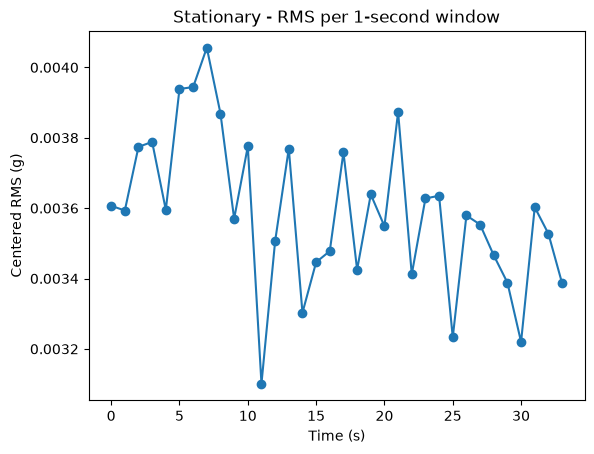

In [6]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(
    stationary_features["start_time_s"],
    stationary_features["rms"],
    marker="o"
)

plt.xlabel("Time (s)")
plt.ylabel("Centered RMS (g)")
plt.title("Stationary - RMS per 1-second window")

plt.show()

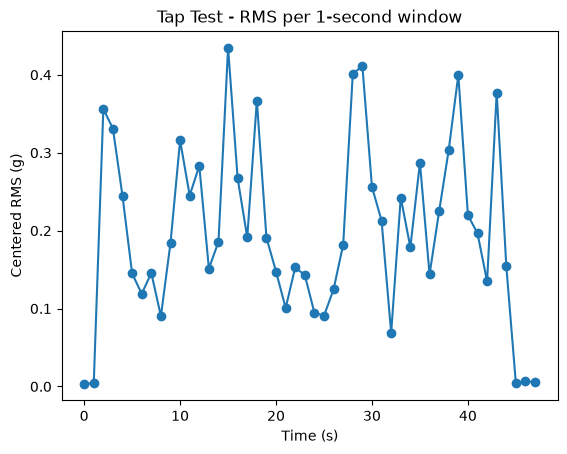

In [7]:
plt.figure()

plt.plot(
    tap_features["start_time_s"],
    tap_features["rms"],
    marker="o"
)

plt.xlabel("Time (s)")
plt.ylabel("Centered RMS (g)")
plt.title("Tap Test - RMS per 1-second window")

plt.show()

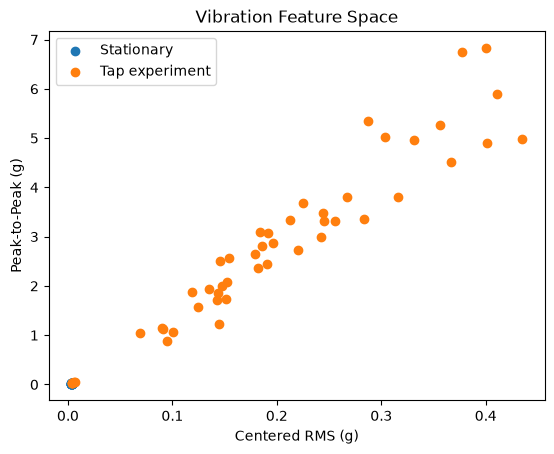

In [8]:
plt.figure()

plt.scatter(
    stationary_features["rms"],
    stationary_features["ptp"],
    label="Stationary"
)

plt.scatter(
    tap_features["rms"],
    tap_features["ptp"],
    label="Tap experiment"
)

plt.xlabel("Centered RMS (g)")
plt.ylabel("Peak-to-Peak (g)")
plt.title("Vibration Feature Space")

plt.legend()
plt.show()